# DCGAN on ONE CIFAR-10 Class (from last-class GAN starter)

This notebook starts from the **last-class GAN** structure (a `GAN` class with `build_generator`, `build_discriminator`, `train`, and `save_imgs`) and updates it to:

- Use **CIFAR-10** instead of MNIST
- Train on **one chosen CIFAR-10 class** (single-mode GAN)
- Replace Dense-only architectures with **Conv2D (Discriminator)** and **Conv2DTranspose / UpSampling (Generator)**
- Demonstrate **control of the noise vector z** (interpolation + single-dimension control)

**Tip (CPU):** Start with small epochs (e.g., 200–800). If you have time, increase.


## 1) Imports + reproducibility

In [7]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

TensorFlow: 2.20.0


## 2) Load CIFAR-10, filter to ONE class

Target: 6 frog
Filtered train shape: (5000, 32, 32, 3)
Using for training: (5000, 32, 32, 3)


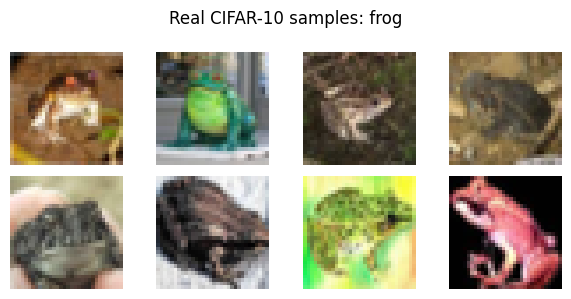

In [8]:
class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

# Choose ONE class to generate (change this)
TARGET_CLASS_NAME = "frog"
TARGET_CLASS = class_names.index(TARGET_CLASS_NAME)
print("Target:", TARGET_CLASS, TARGET_CLASS_NAME)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.squeeze()

# Filter to only the chosen class
x_class = x_train[y_train == TARGET_CLASS]
print("Filtered train shape:", x_class.shape)

# Normalize to [-1, 1] because Generator uses tanh
x_class = (x_class.astype("float32") - 127.5) / 127.5

# Optional CPU cap (raise if you have time)
MAX_TRAIN = 15000
x_class = x_class[:MAX_TRAIN]
print("Using for training:", x_class.shape)

# Visualize real samples
plt.figure(figsize=(6,3))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(((x_class[i]*127.5)+127.5).astype("uint8"))
    plt.axis("off")
plt.suptitle(f"Real CIFAR-10 samples: {TARGET_CLASS_NAME}")
plt.tight_layout()
plt.show()

## 3) GAN class (DCGAN-style Conv/ConvTranspose)

In [9]:
class GAN:
    def __init__(self, img_rows=32, img_cols=32, channels=3, latent_dim=100):
        self.img_rows = img_rows
        self.img_cols = img_cols
        self.channels = channels
        self.img_shape = (img_rows, img_cols, channels)
        self.latent_dim = latent_dim

        optimizer = keras.optimizers.Adam(0.0002, 0.5)

        # Discriminator
        self.discriminator = self.build_discriminator()
        self.discriminator.compile(
            loss=keras.losses.BinaryCrossentropy(from_logits=True),
            optimizer=optimizer,
            metrics=["accuracy"],
        )

        # Generator
        self.generator = self.build_generator()

        # Combined (Generator -> Discriminator)
        z = keras.Input(shape=(self.latent_dim,))
        img = self.generator(z)

        self.discriminator.trainable = False
        validity = self.discriminator(img)

        self.combined = keras.Model(z, validity, name="combined")
        self.combined.compile(
            loss=keras.losses.BinaryCrossentropy(from_logits=True),
            optimizer=optimizer,
        )

    def build_generator(self):
        z = keras.Input(shape=(self.latent_dim,))

        x = layers.Dense(4 * 4 * 256, use_bias=False)(z)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Reshape((4, 4, 256))(x)

        # 4 -> 8
        x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # 8 -> 16
        x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # 16 -> 32
        x = layers.Conv2DTranspose(32, 4, strides=2, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        img = layers.Conv2D(3, 3, padding="same", activation="tanh")(x)
        model = keras.Model(z, img, name="generator")
        return model

    def build_discriminator(self):
        img = keras.Input(shape=self.img_shape)

        x = layers.Conv2D(64, 4, strides=2, padding="same")(img)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Conv2D(128, 4, strides=2, padding="same")(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Conv2D(256, 4, strides=2, padding="same")(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Flatten()(x)
        logits = layers.Dense(1)(x)  # logits
        model = keras.Model(img, logits, name="discriminator")
        return model

    def train(self, X_train, epochs, batch_size=128, save_interval=200):
        half_batch = batch_size // 2

        # Labels for real/fake
        real_y = np.ones((half_batch, 1), dtype=np.float32)
        fake_y = np.zeros((half_batch, 1), dtype=np.float32)

        history = {"d_loss": [], "d_acc": [], "g_loss": []}

        for epoch in range(epochs):
            # ---------------------
            #  Train Discriminator
            # ---------------------
            idx = np.random.randint(0, X_train.shape[0], half_batch)
            real_imgs = X_train[idx]

            noise = np.random.normal(0, 1, (half_batch, self.latent_dim)).astype(np.float32)
            gen_imgs = self.generator.predict(noise, verbose=0)

            d_loss_real = self.discriminator.train_on_batch(real_imgs, real_y)
            d_loss_fake = self.discriminator.train_on_batch(gen_imgs, fake_y)

            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            # ---------------------
            #  Train Generator
            # ---------------------
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim)).astype(np.float32)
            valid_y = np.ones((batch_size, 1), dtype=np.float32)  # fool D

            g_loss = self.combined.train_on_batch(noise, valid_y)

            # Logging
            history["d_loss"].append(float(d_loss[0]))
            history["d_acc"].append(float(d_loss[1]))
            history["g_loss"].append(float(g_loss))

            if epoch % 50 == 0:
                print(f"{epoch} [D loss: {d_loss[0]:.4f}, acc: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")

            if epoch % save_interval == 0:
                self.show_samples(epoch)

        return history

    def show_samples(self, epoch, r=4, c=4):
        noise = np.random.normal(0, 1, (r * c, self.latent_dim)).astype(np.float32)
        gen_imgs = self.generator.predict(noise, verbose=0)

        # Rescale to [0,1] for display
        imgs = (gen_imgs * 0.5) + 0.5

        plt.figure(figsize=(c*2, r*2))
        for i in range(r*c):
            plt.subplot(r, c, i+1)
            plt.imshow(np.clip(imgs[i], 0, 1))
            plt.axis("off")
        plt.suptitle(f"Generated samples @ step {epoch}")
        plt.tight_layout()
        plt.show()

## 4) Instantiate models + train


Generator summary:


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 8, 8, 128)      │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 16, 16, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 32, 32, 32)     │        32,768 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,115,875 (4.26 MB)

 Trainable params: 1,107,235 (4.22 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662,977 (2.53 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 662,977 (2.53 MB)

0 [D loss: 0.6809, acc: 25.00%] [G loss: 0.6841]


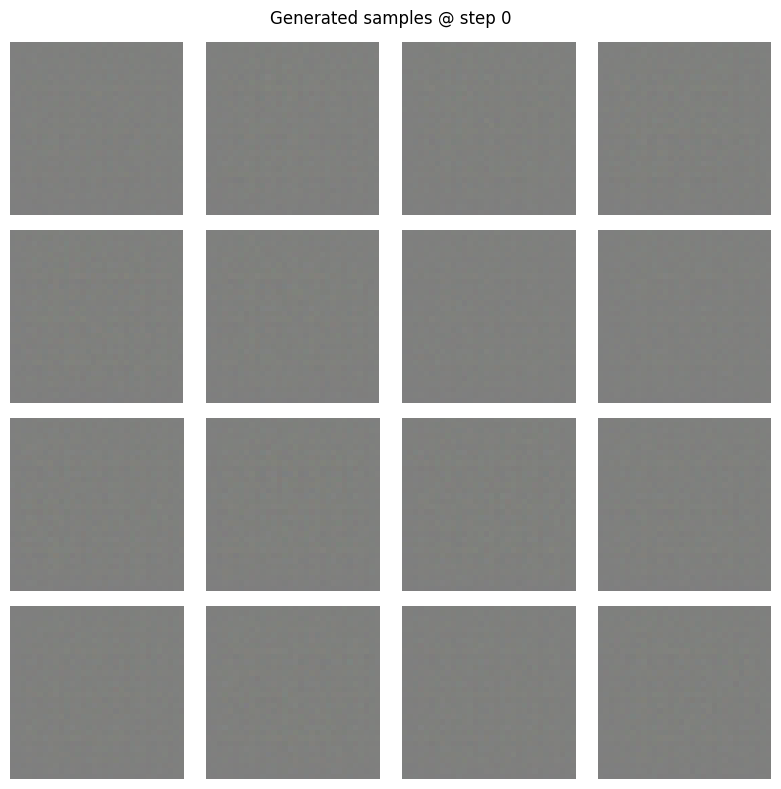

50 [D loss: 0.7039, acc: 49.75%] [G loss: 0.3363]
100 [D loss: 0.7329, acc: 49.79%] [G loss: 0.2632]
150 [D loss: 0.7783, acc: 36.71%] [G loss: 0.2285]
200 [D loss: 0.8371, acc: 27.56%] [G loss: 0.2079]


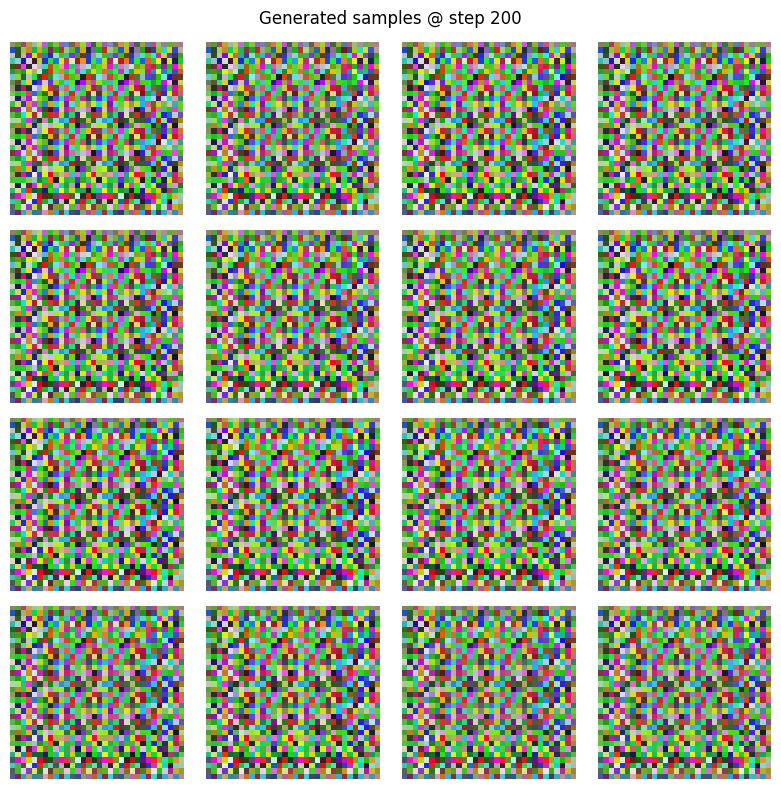

250 [D loss: 0.9012, acc: 22.07%] [G loss: 0.1934]
300 [D loss: 0.9629, acc: 18.40%] [G loss: 0.1823]
350 [D loss: 1.0194, acc: 15.78%] [G loss: 0.1727]
400 [D loss: 1.0720, acc: 13.81%] [G loss: 0.1639]


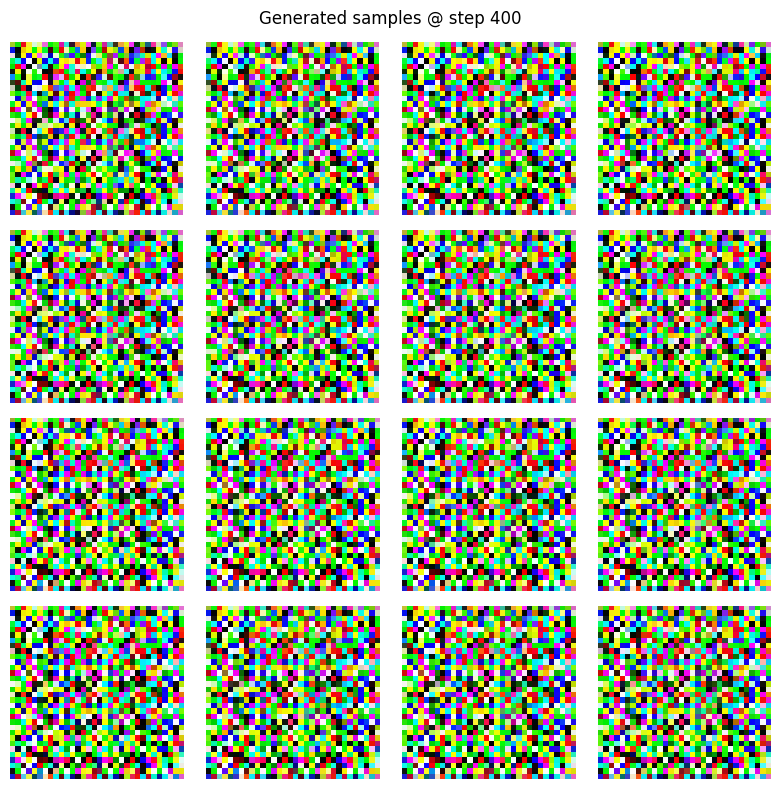

450 [D loss: 1.1225, acc: 12.28%] [G loss: 0.1557]
500 [D loss: 1.1705, acc: 11.05%] [G loss: 0.1481]
550 [D loss: 1.2156, acc: 10.05%] [G loss: 0.1412]
600 [D loss: 1.2566, acc: 9.21%] [G loss: 0.1351]


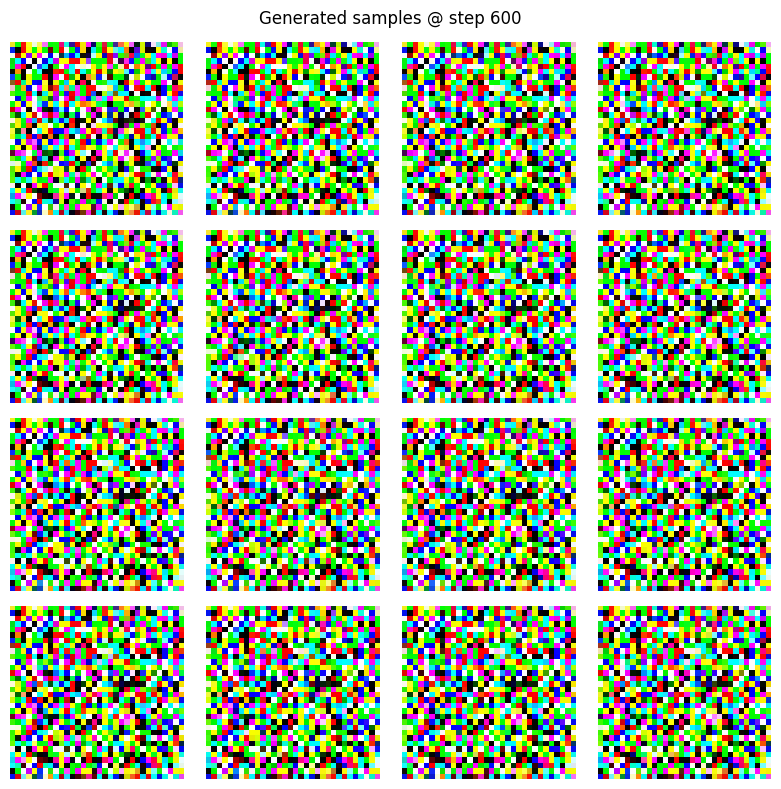

650 [D loss: 1.2932, acc: 8.50%] [G loss: 0.1296]
700 [D loss: 1.3263, acc: 7.90%] [G loss: 0.1248]
750 [D loss: 1.3559, acc: 7.37%] [G loss: 0.1204]
800 [D loss: 1.3826, acc: 6.91%] [G loss: 0.1166]


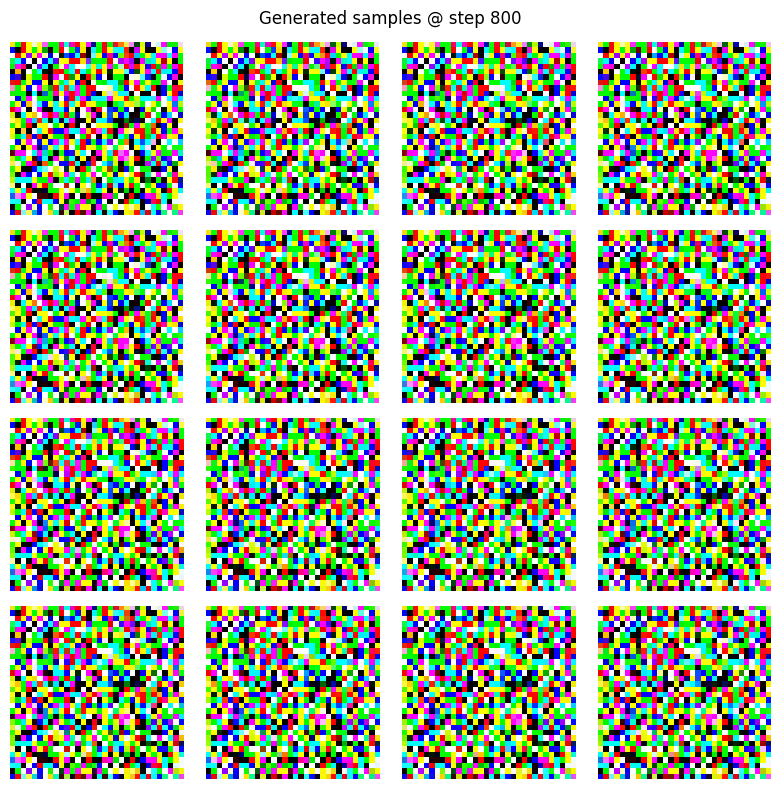

850 [D loss: 1.4066, acc: 6.50%] [G loss: 0.1131]
900 [D loss: 1.4284, acc: 6.14%] [G loss: 0.1100]
950 [D loss: 1.4481, acc: 5.82%] [G loss: 0.1071]
1000 [D loss: 1.4663, acc: 5.53%] [G loss: 0.1045]


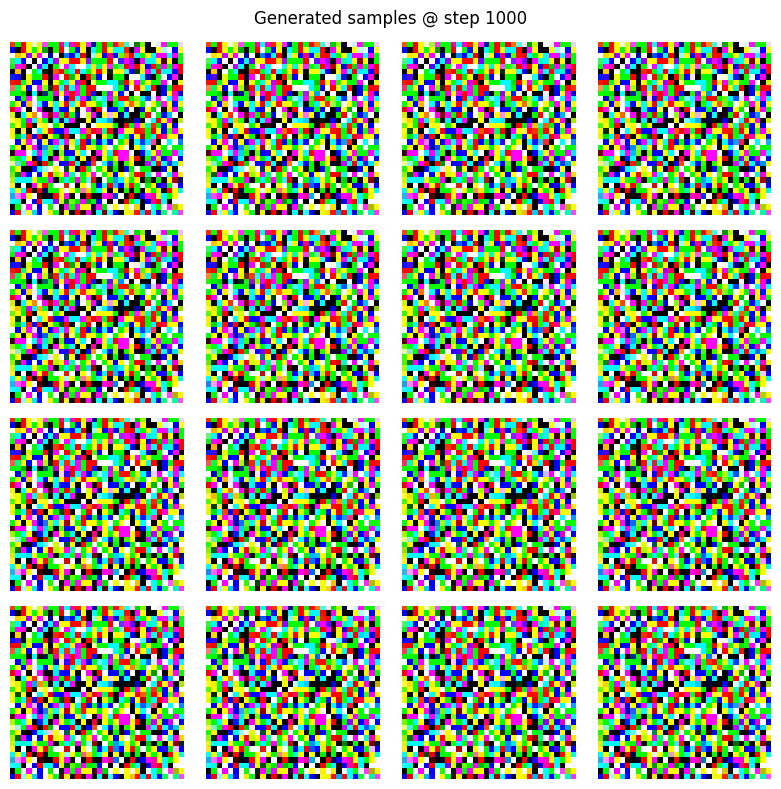

1050 [D loss: 1.4830, acc: 5.27%] [G loss: 0.1021]
1100 [D loss: 1.4983, acc: 5.03%] [G loss: 0.1000]
1150 [D loss: 1.5125, acc: 4.81%] [G loss: 0.0980]
1200 [D loss: 1.5256, acc: 4.61%] [G loss: 0.0961]


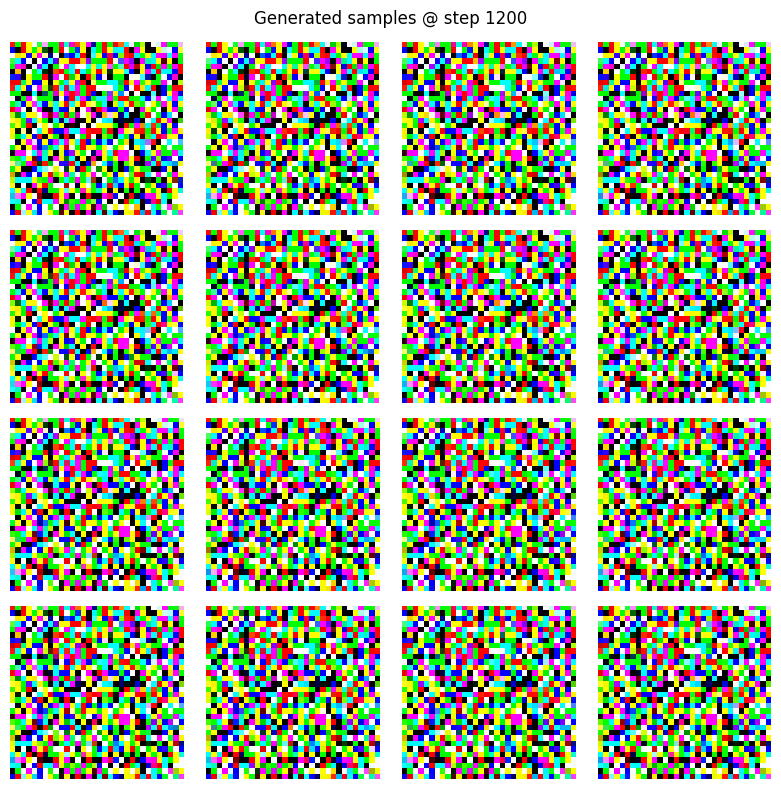

1250 [D loss: 1.5378, acc: 4.42%] [G loss: 0.0944]
1300 [D loss: 1.5492, acc: 4.25%] [G loss: 0.0928]
1350 [D loss: 1.5598, acc: 4.10%] [G loss: 0.0913]
1400 [D loss: 1.5698, acc: 3.95%] [G loss: 0.0899]


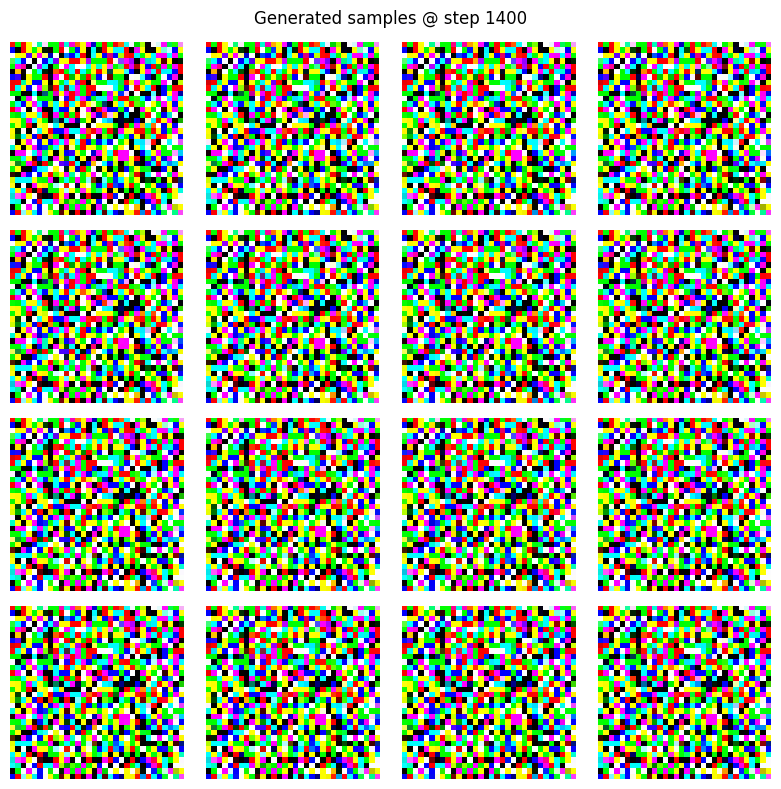

1450 [D loss: 1.5791, acc: 3.81%] [G loss: 0.0886]
1500 [D loss: 1.5880, acc: 3.69%] [G loss: 0.0873]
1550 [D loss: 1.5962, acc: 3.57%] [G loss: 0.0862]
1600 [D loss: 1.6040, acc: 3.46%] [G loss: 0.0851]


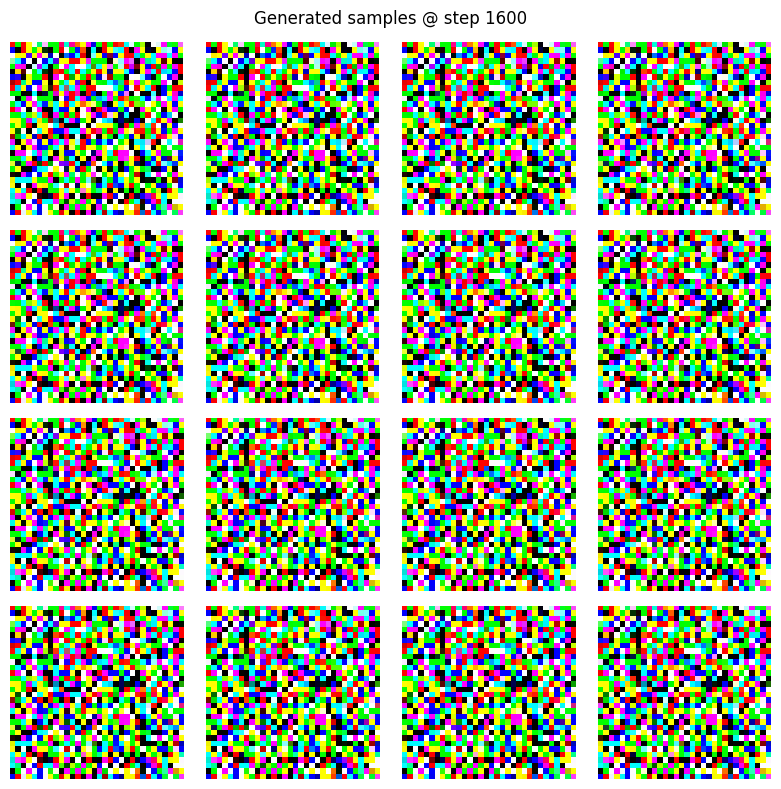

1650 [D loss: 1.6116, acc: 3.35%] [G loss: 0.0840]
1700 [D loss: 1.6187, acc: 3.25%] [G loss: 0.0830]
1750 [D loss: 1.6254, acc: 3.16%] [G loss: 0.0821]
1800 [D loss: 1.6318, acc: 3.07%] [G loss: 0.0812]


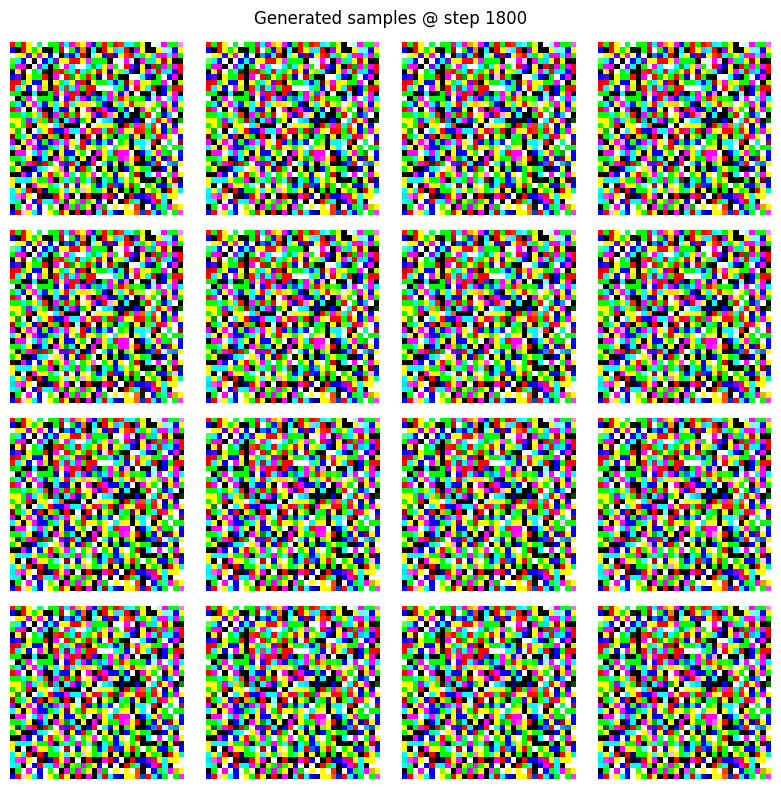

1850 [D loss: 1.6379, acc: 2.99%] [G loss: 0.0804]
1900 [D loss: 1.6438, acc: 2.91%] [G loss: 0.0796]
1950 [D loss: 1.6494, acc: 2.84%] [G loss: 0.0788]
Training minutes: 12.89


In [10]:
gan = GAN(img_rows=32, img_cols=32, channels=3, latent_dim=100)

print("\nGenerator summary:")
gan.generator.summary()
print("\nDiscriminator summary:")
gan.discriminator.summary()

# CPU-friendly training suggestion:
# - Start with 400–800 steps (not epochs over full dataset)
#   Here, 'epochs' is actually training steps in this starter loop.
STEPS = 2000
BATCH_SIZE = 128
SAVE_INTERVAL = 200

t0 = time.time()
history = gan.train(x_class, epochs=STEPS, batch_size=BATCH_SIZE, save_interval=SAVE_INTERVAL)
print("Training minutes:", round((time.time() - t0) / 60, 2))

## 5) Plot losses

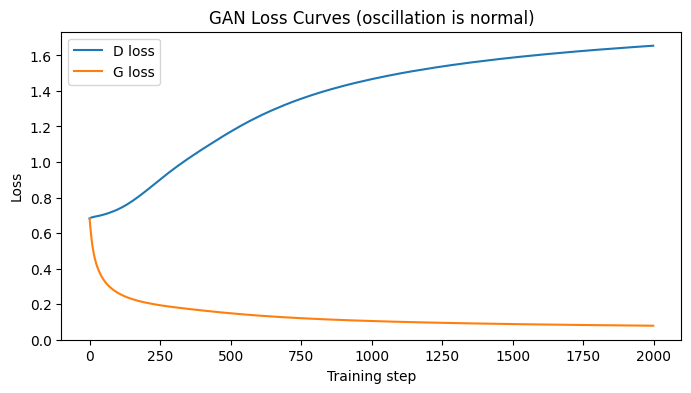

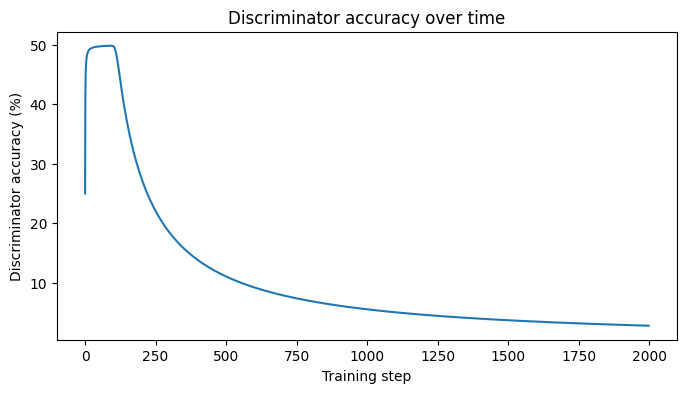

In [11]:
plt.figure(figsize=(8,4))
plt.plot(history["d_loss"], label="D loss")
plt.plot(history["g_loss"], label="G loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GAN Loss Curves (oscillation is normal)")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(np.array(history["d_acc"]) * 100)
plt.xlabel("Training step")
plt.ylabel("Discriminator accuracy (%)")
plt.title("Discriminator accuracy over time")
plt.show()

## 6) Noise control: interpolation and single-dimension control

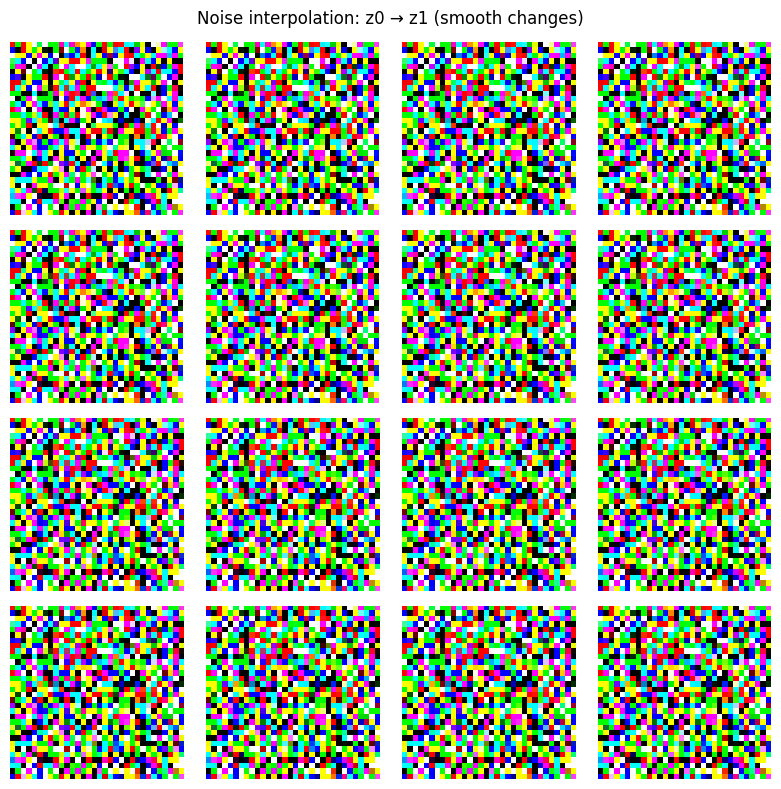

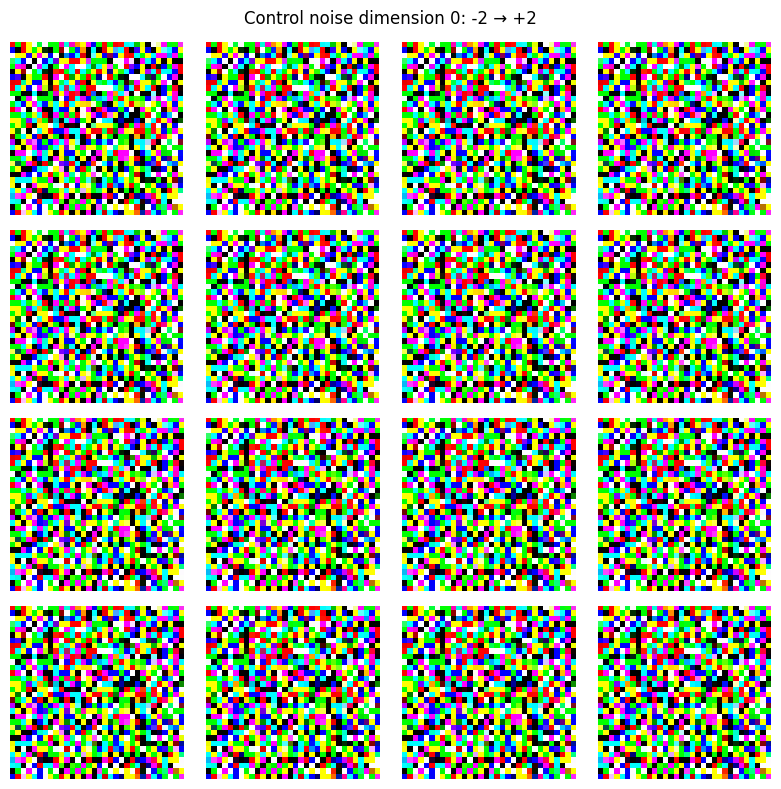

In [12]:
LATENT_DIM = gan.latent_dim

def grid_show(gen_imgs, title, n=16):
    imgs = (gen_imgs * 0.5) + 0.5
    k = int(np.sqrt(n))
    plt.figure(figsize=(k*2, k*2))
    for i in range(n):
        plt.subplot(k, k, i+1)
        plt.imshow(np.clip(imgs[i], 0, 1))
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# 6.1 Interpolation between two z vectors
z0 = np.random.normal(0, 1, (1, LATENT_DIM)).astype(np.float32)
z1 = np.random.normal(0, 1, (1, LATENT_DIM)).astype(np.float32)

alphas = np.linspace(0, 1, 16).astype(np.float32)
Z = np.vstack([(1-a)*z0 + a*z1 for a in alphas])

imgs = gan.generator.predict(Z, verbose=0)
grid_show(imgs, "Noise interpolation: z0 → z1 (smooth changes)", n=16)

# 6.2 Control ONE dimension of z
z_base = np.random.normal(0, 1, (1, LATENT_DIM)).astype(np.float32)
dim = 0
vals = np.linspace(-2.0, 2.0, 16).astype(np.float32)

Z2 = np.repeat(z_base, repeats=16, axis=0)
Z2[:, dim] = vals

imgs2 = gan.generator.predict(Z2, verbose=0)
grid_show(imgs2, f"Control noise dimension {dim}: -2 → +2", n=16)

## 7) Conclusion (fill-in, copy-paste)

- We started from the last-class GAN starter code and replaced Dense-only networks with **DCGAN-style Conv/ConvTranspose** architectures.
- We trained the GAN on **only one CIFAR-10 class** (**{TARGET_CLASS_NAME}**) so the generator learns a single-class image distribution.
- Generated samples improved as training progressed (early steps: noisy blobs; later steps: more class-consistent textures/shapes).
- **Noise control:**
  - Interpolating between two noise vectors produces smooth transitions in generated images.
  - Varying one latent dimension while holding others fixed isolates a controllable factor in the output.
- GAN losses oscillate; visual quality is the main indicator of progress.
